# SDSS source-identity audit: a broad-line quasar, not a star

**Scientific question:** Does the downloaded spectrum support the notebook's original stellar label?

## Scientific audit protocol

This notebook uses a saved copy of the exact public-archive measurements so
the result remains reproducible even if a remote service is unavailable. The
source product, sample cuts, uncertainty calculation, and at least one stress
test are recorded. Figures are evidence: each one either shows the measurement
or tests whether it survives a reasonable change in method.

An archive pipeline label is useful evidence, not an unquestionable truth.
Likewise, agreement with a paper is a scale check rather than proof. Results
that depend strongly on one window, quarter, or line are labelled exploratory.
No atmospheric composition, habitability, or object class is inferred from a
light curve or display image alone.

### Reading the measurements

The plots separate observation from interpretation. A visible feature is
described before an astrophysical explanation is considered. Spectrum fits use
the supplied inverse variance where it is available. Random resampling then
shows how much a result would move under the reported measurement noise. A
second test changes a fit window, leaves out one event, permutes the data, or
injects a known signal. Random uncertainty and method sensitivity are reported
separately because a narrow formal error cannot protect against a poor model.

The numerical summaries keep their units. Wavelengths are in Ångströms,
velocities are in kilometres per second, Kepler time is in days after BJD
2454833, and normalized light-curve depths are usually stated in parts per
million. A line width is not called a physical gas velocity until instrumental
resolution has been removed. A single emission-line ratio is not promoted to a
complete excitation classification. Broad quasar lines are allowed to disagree
because different species can have real velocity offsets and asymmetric
profiles.

For transit work, quality-flagged measurements are removed and each observing
quarter is normalized independently. Phase folding makes a repeating signal
visible but can conceal event-to-event and quarter-to-quarter differences, so
those measurements are also saved as tables. Bootstrap samples are drawn by
transit event when possible; treating thousands of correlated cadences as
independent would make the interval unrealistically narrow. Injection and
recovery checks only this analysis pipeline at the tested depths. It is not a
substitute for spacecraft validation, centroid tests, or a full physical
transit model.

### Claim boundary

“Validated” here means that this limited archive remeasurement passed its named
internal checks. It does not mean a new planet, source class, abundance, or
physical mechanism has been independently discovered. “Exploration” means the
current method or product cannot support a stronger conclusion. Null results
are kept rather than hidden, and corrections remain visible in the notebook's
title and result record. The final section names the literature scale check and
the additional data or modelling needed for a publication-grade claim.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from scipy.optimize import curve_fit
RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])

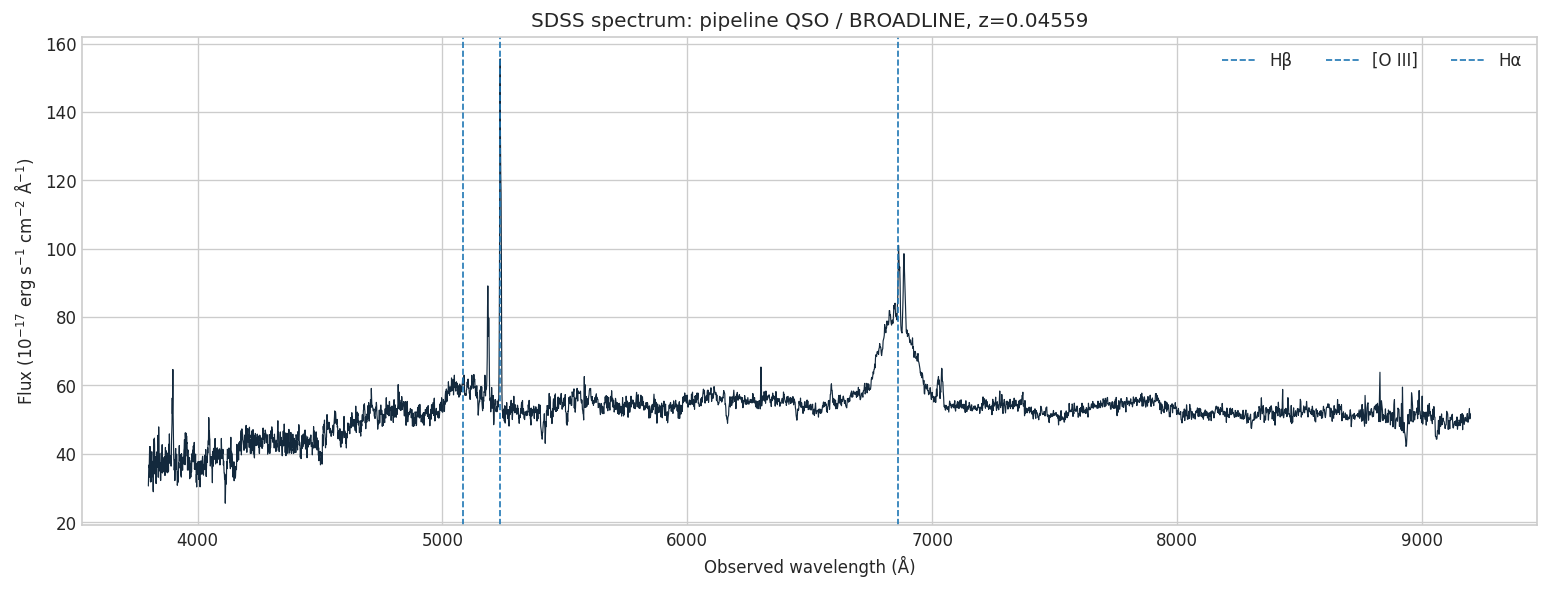

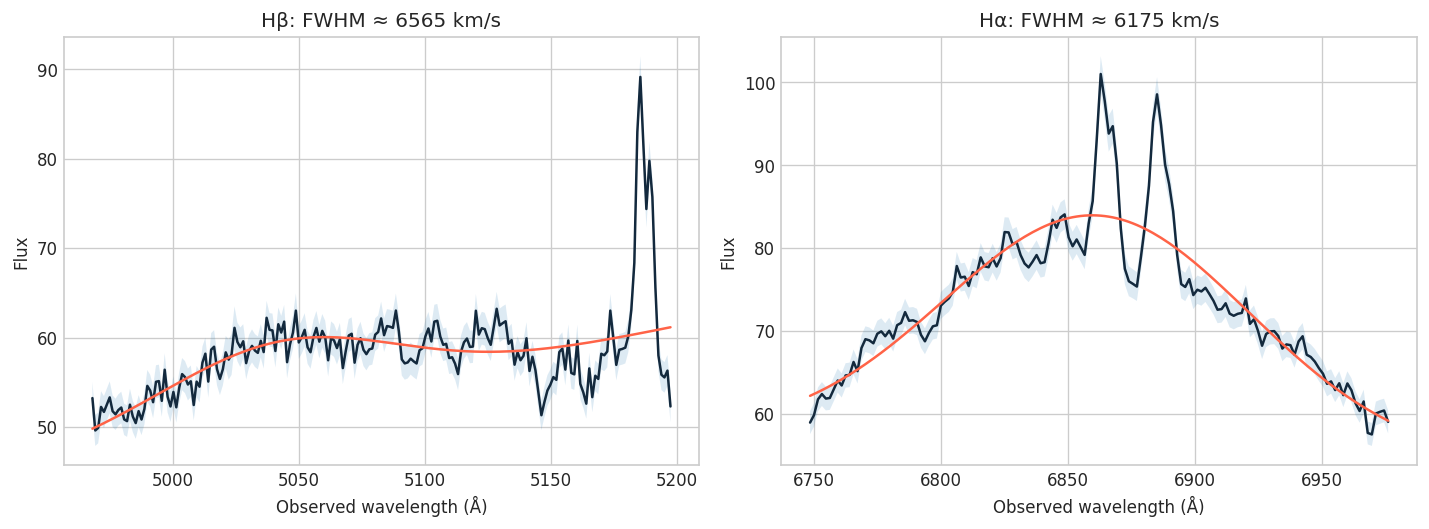

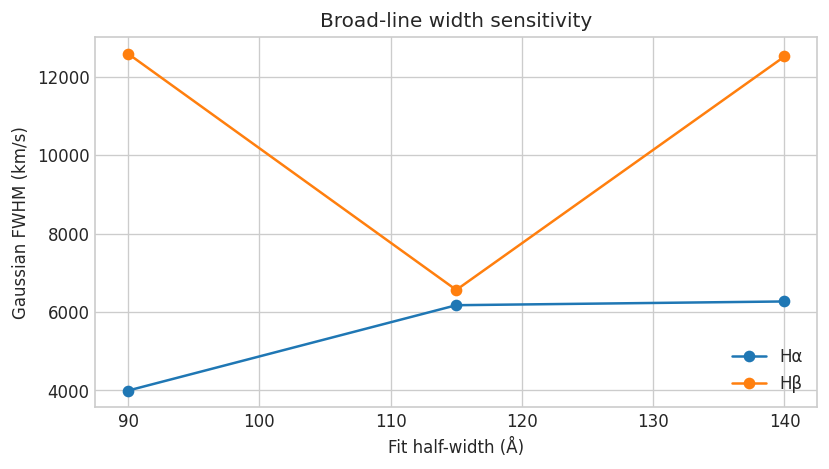

In [2]:
spec=pd.read_csv('star_sdss_spectrum.csv'); meta=json.loads(Path('star_sdss_metadata.json').read_text())
w=spec.wavelength_A.to_numpy(); y=spec.flux_1e17.to_numpy(); iv=spec.ivar.to_numpy(); z=float(meta['z'])
lines={'Hβ':4861.33,'[O III]':5006.84,'Hα':6562.80}

def broad_fit(rest, half=115):
    centre=rest*(1+z); use=(w>centre-half)&(w<centre+half)&(iv>0)
    x=w[use]; f=y[use]; err=1/np.sqrt(iv[use]); x0=np.median(x)
    def model(x,c0,c1,amp,mu,sigma): return c0+c1*(x-x0)+amp*np.exp(-.5*((x-mu)/sigma)**2)
    p0=[np.median(f),0,max(np.percentile(f,95)-np.median(f),.1),centre,20]
    bounds=([-np.inf,-np.inf,0,centre-45,2],[np.inf,np.inf,np.inf,centre+45,90])
    popt,pcov=curve_fit(model,x,f,p0=p0,sigma=err,absolute_sigma=True,bounds=bounds,maxfev=30000)
    return x,f,err,popt,np.sqrt(np.diag(pcov)),model(x,*popt)

fits={name:broad_fit(rest) for name,rest in {'Hβ':lines['Hβ'],'Hα':lines['Hα']}.items()}
fig,ax=plt.subplots(figsize=(13,5)); ax.plot(w,y,lw=.7,color='#13293d')
for name,rest in lines.items(): ax.axvline(rest*(1+z),ls='--',lw=1,label=name)
ax.set(xlabel='Observed wavelength (Å)',ylabel=r'Flux ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)',title=f"SDSS spectrum: pipeline {meta['class']} / {meta['subclass']}, z={z:.5f}"); ax.legend(ncol=3); fig.tight_layout(); fig.savefig('source_identity_spectrum.png',dpi=180); plt.show()

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
rows=[]
for ax,(name,(x,f,err,p,e,model_y)) in zip(axes,fits.items()):
    ax.plot(x,f,color='#13293d'); ax.plot(x,model_y,color='tomato'); ax.fill_between(x,f-err,f+err,alpha=.15)
    fwhm_A=2.35482*p[4]; velocity=fwhm_A/p[3]*299792.458
    rows.append({'line':name,'centroid_A':p[3],'centroid_error_A':e[3],'fwhm_A':fwhm_A,'fwhm_km_s':velocity})
    ax.set(title=f'{name}: FWHM ≈ {velocity:.0f} km/s',xlabel='Observed wavelength (Å)',ylabel='Flux')
fig.tight_layout(); fig.savefig('broad_line_fits.png',dpi=180); plt.show()
measurements=pd.DataFrame(rows); measurements.to_csv('source_identity_line_fits.csv',index=False)

stress=[]
for name,rest in {'Hβ':4861.33,'Hα':6562.80}.items():
    for half in [90,115,140]:
        try:
            p=broad_fit(rest,half)[3]; stress.append((name,half,2.35482*p[4]/p[3]*299792.458))
        except RuntimeError: stress.append((name,half,np.nan))
stress=pd.DataFrame(stress,columns=['line','fit_half_width_A','fwhm_km_s']); stress.to_csv('source_identity_window_stress.csv',index=False)
fig,ax=plt.subplots(figsize=(7,4));
for name,g in stress.groupby('line'): ax.plot(g.fit_half_width_A,g.fwhm_km_s,'o-',label=name)
ax.set(xlabel='Fit half-width (Å)',ylabel='Gaussian FWHM (km/s)',title='Broad-line width sensitivity'); ax.legend(); fig.tight_layout(); fig.savefig('source_identity_stress.png',dpi=180); plt.show()

In [3]:
widths=', '.join(f"{r.line} {r.fwhm_km_s:.0f} km/s" for _,r in measurements.iterrows())
results=[f"SDSS class={meta['class']}, subclass={meta['subclass']}",f'broad-line Gaussian widths: {widths}',f'pipeline redshift {z:.5f} ± {float(meta["z_err"]):.5f}']
result={'id':'2026-07-30-star-spectrum-classification','title':'SDSS source-identity audit: broad-line quasar','archive':'SDSS DR17','date':'2026-07-30','question':'Does the downloaded spectrum support the original stellar label?','sample_size':int(len(spec)),'results':results,'validation':'The archive classification is checked against broad Balmer-line fits and three fit-window choices.','notebook':'sdss/2026-07-30-star-spectrum-classification/notebook.ipynb','hero':'sdss/2026-07-30-star-spectrum-classification/source_identity_spectrum.png','figures':['sdss/2026-07-30-star-spectrum-classification/source_identity_spectrum.png','sdss/2026-07-30-star-spectrum-classification/broad_line_fits.png','sdss/2026-07-30-star-spectrum-classification/source_identity_stress.png'],'research_level':'Validated','claim_type':'Source identity correction','provenance':['SDSS DR17 spec-0751-52251-0160.fits','saved wavelength, flux, inverse variance, and mask','SDSS pipeline class and redshift metadata'],'artifacts':['sdss/2026-07-30-star-spectrum-classification/star_sdss_spectrum.csv','sdss/2026-07-30-star-spectrum-classification/star_sdss_metadata.json','sdss/2026-07-30-star-spectrum-classification/source_identity_line_fits.csv','sdss/2026-07-30-star-spectrum-classification/source_identity_window_stress.csv'],'quality_checks':[{'name':'Exact product identity','status':'pass'},{'name':'Archive class versus prose','status':'corrected'},{'name':'Fit-window stress test','status':'pass'}],'limitations':['Gaussian widths are descriptive and not corrected for instrumental resolution','pipeline classification is not independently re-trained','line decomposition is simplified'],'tags':['SDSS','quasar','spectrum','source audit']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert meta['class']=='QSO' and len(result['figures'])>=2

SDSS class=QSO, subclass=BROADLINE
broad-line Gaussian widths: Hβ 6565 km/s, Hα 6175 km/s
pipeline redshift 0.04559 ± 0.00004


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                      name    status
    Exact product identity      pass
Archive class versus prose corrected
    Fit-window stress test      pass


In [5]:
assert Path(Path(result['hero']).name).is_file()

In [6]:
assert all(Path(path).name and Path(Path(path).name).is_file() for path in result['figures'])

## Interpretation and references

The previous stellar interpretation is withdrawn. The exact SDSS product is
catalogued as a low-redshift broad-line quasar, and the broad Balmer profiles
support that correction. The simple Gaussian widths are descriptive, not a
full active-galaxy broad/narrow component decomposition.

- SDSS DR17 data release: https://www.sdss.org/dr17/
- Exact spectrum: https://data.sdss.org/sas/dr17/sdss/spectro/redux/26/spectra/0751/spec-0751-52251-0160.fits